# Tarefa de Machine Learning: regressão e classificação

Feito por: João Rodrigo

Importando:

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Parte 1: Regressão 

### 1.1 e 1.2 - Análise exploratória, limpeza e pré-processamento

In [135]:
train_df = pd.read_csv('regressao/train.csv')
test_df = pd.read_csv('regressao/test.csv')

In [136]:
# dando uma olhada
train_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [137]:
test_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,M,16,U,LE3,T,2,2,other,services,...,yes,yes,yes,1,5,3,1,1,5,6
1,GP,F,15,U,LE3,T,2,1,other,other,...,yes,no,no,5,5,3,2,1,3,6
2,GP,M,16,U,GT3,A,1,4,services,teacher,...,no,yes,no,5,3,2,1,2,1,0
3,GP,F,16,U,LE3,T,4,4,other,services,...,yes,yes,no,4,2,4,1,3,4,58
4,GP,F,18,R,GT3,T,3,3,teacher,other,...,yes,no,yes,2,1,3,1,1,1,5


Vemos a presença de diversas colunas categóricas.

Vamos dar uma olhada também no student.txt:

In [138]:
with open('regressao/student.txt', 'r') as f:
    print(f.read())

# Attributes for train.csv (Math course) datasets:
1 school - student's school (binary: "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira)
2 sex - student's sex (binary: "F" - female or "M" - male)
3 age - student's age (numeric: from 15 to 22)
4 address - student's home address type (binary: "U" - urban or "R" - rural)
5 famsize - family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)
6 Pstatus - parent's cohabitation status (binary: "T" - living together or "A" - apart)
7 Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
8 Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
9 Mjob - mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or "other")
10 Fjob - father's job (nominal: "teacher", "health

Vejamos se será necessário realizar limpeza:

In [139]:
# verifica quantidade de dados nulos por coluna
print(train_df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
score         0
dtype: int64


In [140]:
# verifica se ha linhas idênticas duplicadas
print(train_df.duplicated().sum())

0


Tudo parece ok. O único pré-processamento necessário será converter as colunas de texto (vistas no students.txt) em números, que será feita no pipeline a seguir.

### 1.3 e 1.4 - Modelo de inferência e métrica de avaliação

Utilizaremos o `RandomForestRegressor` e o one-hot-encoding nas colunas categóricas. 

A métrica utilizada para avaliar o desempenho será o RMSE (Root Mean Squared Error), como solicitado:

$$ RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 } $$

Vamos começar isolando a coluna de score para que o modelo não tenha essa informação enquanto aprende.

In [141]:
X = train_df.drop(columns=['score'])
y = train_df['score'] # será nosso alvo

Separando os dados em dois, 80% para o treino e 20% para o teste:

In [142]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=3005)

Antes de realizar o `.fit`, vamos fazer o one-hot-encoding citado anteriormente para que as colunas categóricas assumam valores numéricos binários.

In [143]:
# identifica as colunas de texto 
col_categoricas = X.select_dtypes(include=['object', 'string']).columns.tolist()

# cria transformador para aplicar o one-hot encoding 
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), col_categoricas)],
    remainder='passthrough'
)

# cria pipeline unindo o pre-processamento e o modelo escolhido
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=3005))
])

Agora sim:

In [144]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['school','sex','age',...,'Walc','health','absences']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the out

Calculando o erro com base no conjunto de validação:

In [145]:
# gera previsoes com base nos 20% (X_val) e calcula o rmse
prev = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, prev))
print(f"RMSE: {rmse:.4f}")

RMSE: 3.2143


Text(0, 0.5, 'nota prevista')

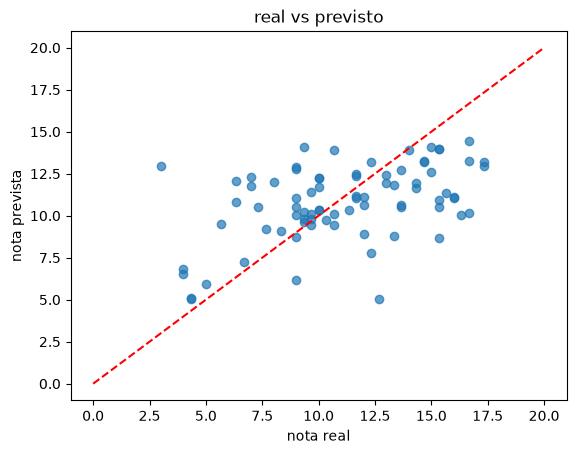

In [146]:
plt.scatter(y_val, prev, alpha=0.7)
# desenha uma linha vermelha tracejada que representa o acerto perfeito
plt.plot([0, 20], [0, 20], color='red', linestyle='--')
plt.title('real vs previsto')
plt.xlabel('nota real')
plt.ylabel('nota prevista')

Vemos algumas tendências nesse modelo: ele tem dificuldade de prever valores extremos e, também, de prever aqueles com nota real superior a 15, já que todos nessa faixa se encontram abaixo da linha vermelha que representa o acerto.

## Parte 2: Classificação

Vamos fazer um processo semelhante ao anterior. Para a classificação, escolhi o modelo de `KNeighborsClassifier`.

In [147]:
train_2 = pd.read_csv('classificacao/train2.csv')
test_2 = pd.read_csv('classificacao/test2.csv')

In [148]:
train_2.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Vemos que há somente uma coluna categórica: a `diagnosis`. Com isso, podemos mapear da seguinte forma:

In [149]:
# mapeia benigno pra 0 e maligno pra 1
train_2['diagnosis'] = train_2['diagnosis'].map({'B': 0, 'M': 1})

Agora, criando e treinando o modelo de classificação (com StandardScaler para garantir que todas as observações tenham mesmo peso no modelo):

In [150]:
# fazendo o processo semelhante ao do modelo de regressão
X = train_2.drop(columns=['diagnosis'])
y = train_2['diagnosis']

# divide dados (80/20)
X_2_train, X_2_val, y_2_train, y_2_val = train_test_split(X, y, test_size=0.2, random_state=3005)

# treina modelo
model_2 = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier())
])
model_2.fit(X_2_train, y_2_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Vejamos a métrica de acurácia (fração de acertos) solicitada:

In [151]:
# valida e calcula acuracia
prev2 = model_2.predict(X_2_val)
acc = accuracy_score(y_2_val, prev2)
print(f"acurácia: {acc:.4f}")

acurácia: 0.9912


Tivemos uma acurácia de 99,12%, o que é bem agradável para o modelo. Vejamos agora a matriz de confusão:

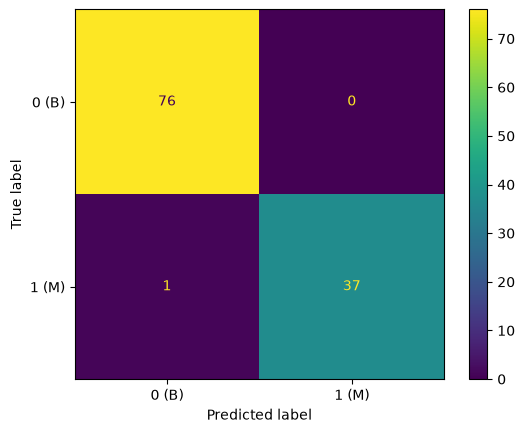

In [152]:
cm = confusion_matrix(y_2_val, prev2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0 (B)', '1 (M)'])
disp.plot()
plt.show()

Assim, tivemos 76 negativos verdadeiros, 37 positivos verdadeiros, nenhum falso positivo e 1 falso negativo, que foi a razão para a acurácia não ser máxima.

## Parte 3: Arquivos de submissão

In [153]:
test_df_preds = model.predict(test_df)

test_df_preds = np.clip(test_df_preds, 0, 20)

submission = pd.DataFrame({
    'id': test_df.index, 
    'score': test_df_preds
})

submission.to_csv('joao_rodrigo_submissao_regressao.csv', index=False)

In [154]:
test_2_preds = model_2.predict(test_2)

submission = pd.DataFrame({
    'id': test_2.index, 
    'diagnosis': test_2_preds
})
submission.to_csv('joao_rodrigo_submissao_classificacao.csv', index=False)